In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset from Google Drive
df = pd.read_pickle("/content/drive/MyDrive/dataset.pkl")

# Check the distribution of the target variable 'class'
print(df['class'].value_counts())

# Calculate the average thickness deviation for each class to see if there is a clear difference
print(df.groupby('class')['EXIT_THICK_DEVIATION_ABS_AVG'].mean())

class
1    201310
0    110232
Name: count, dtype: int64
class
0    3.538271
1    3.619030
Name: EXIT_THICK_DEVIATION_ABS_AVG, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311542 entries, 0 to 311541
Data columns (total 60 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coil_id                       311542 non-null  int64  
 1   pass_nr                       311542 non-null  float64
 2   REF_INITIAL_THICKNESS         311542 non-null  float64
 3   REF_TARGET_THICKNESS          311542 non-null  float64
 4   velocity_mdr                  311542 non-null  float64
 5   tension_en                    311542 non-null  float64
 6   tension_ex                    311542 non-null  float64
 7   h_exit_ref                    311542 non-null  float64
 8   h_entry_ref                   311542 non-null  float64
 9   dh_entry                      311542 non-null  float64
 10  dh_entry_med                  311542 non-null  float64
 11  dh_entry_std                  311542 non-null  float64
 12  dh_entry_max                  311542 non-nul


# **FEATURE CATEGORIZATION**

This dataset contains **60 columns** representing metadata, process variables, chemical compositions, and quality indicators for rolling mill operations.


### 🔹 1. Identifier / Metadata Features

These features are **non-predictive identifiers** and do not contribute to the learning process.

* **coil_id**: Unique identifier for each coil (**to be dropped**)
* **pass_nr**: Rolling pass number (**important process indicator, should be retained**)


### 🔹 2. Reference / Target Thickness Parameters

These represent **desired or theoretical thickness values** used as control references.

* **REF_INITIAL_THICKNESS / REF_TARGET_THICKNESS**
* **h_entry_ref / h_exit_ref**


### 🔹 3. Process Operational Parameters

These are **core machine control variables** that directly influence thickness and quality.

* **Speed Variables**: `velocity_mdr`, `velocity_en`, `velocity_ex`
* **Tension Variables**: `tension_en`, `tension_ex`
* **Gap / Reduction Variables**: `dh_entry`, `dm_bur`, `dm_imr1`, `dm_imr2lr`, `dm_imr2m`, `dm_wrbot`, `dm_wrtop`, `rgc_act`


### 🔹 4. Statistical / Aggregated Process Features

These are **derived features** (median, standard deviation, minimum, maximum) representing steady-state behavior of the process.

* **Entry Thickness Stats**: `dh_entry_med`, `dh_entry_std`, `dh_entry_max`, `dh_entry_min`
* **Velocity Stats**: `velocity_en_max`, `velocity_en_min`, `velocity_en_med`, `velocity_en_std`, etc.


### 🔹 5. Chemical Composition Features

These represent **material properties of the steel**, which influence deformation behavior but are not direct process controls.

* **Elements**: C, SI, MN, S, P, CR, NI, CU, AL, SN, MO, V, TI, NB, W, N, CO, ZR, B, TE, PB, SB, CA, TA, CE, LA


### 🔹 6. Quality Indicators

These are **output performance metrics** that measure deviation from desired thickness.

* **EXIT_THICK_DEVIATION_ABS_AVG**
* **EXIT_THICK_DEVIATION_AVG**


### 🔹 7. Target Variable (FINAL SELECTION)

* **EXIT_THICK_DEVIATION_AVG**:
  Selected as the **primary target variable** for this study. It represents the **average deviation of exit thickness from the desired value**, making it a direct indicator of process quality and suitable for **regression modeling and anomaly detection**.


### 🔹 8. Class Variable

* **class**: Binary category (0 / 1)





In [ ]:
df.head()

,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG,class
0,0,1.0,4.225625,0.788363,425.688153,50.745343,551.133469,3.091959,4.225625,-0.082746,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,8.993787,-1.084073,1
1,0,1.0,4.225625,0.788363,425.682418,50.747165,551.090899,3.091959,4.225625,-0.079769,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.804850,1.363289,1
2,0,1.0,4.225625,0.788363,425.682424,50.747157,551.090893,3.091959,4.225625,-0.079770,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.806373,1.362700,1
3,0,1.0,4.225625,0.788363,425.781351,50.736857,550.966360,3.091959,4.225625,-0.080857,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.584936,-0.297517,1
4,0,1.0,4.225625,0.788363,425.648795,50.728522,551.028239,3.091959,4.225625,-0.080740,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,11.089441,-4.554978,1


In [ ]:
print(df.shape)

(311542, 60)


In [ ]:
df.columns

Index(['coil_id', 'pass_nr', 'REF_INITIAL_THICKNESS', 'REF_TARGET_THICKNESS',
       'velocity_mdr', 'tension_en', 'tension_ex', 'h_exit_ref', 'h_entry_ref',
       'dh_entry', 'dh_entry_med', 'dh_entry_std', 'dh_entry_max',
       'dh_entry_min', 'dm_bur', 'dm_imr1', 'dm_imr2lr', 'dm_imr2m',
       'dm_wrbot', 'dm_wrtop', 'rgc_act', 'velocity_en', 'velocity_en_max',
       'velocity_en_min', 'velocity_en_med', 'velocity_en_std', 'velocity_ex',
       'velocity_ex_max', 'velocity_ex_min', 'velocity_ex_med',
       'velocity_ex_std', 'C', 'SI', 'MN', 'S', 'P', 'CR', 'NI', 'CU', 'AL',
       'SN', 'MO', 'V', 'TI', 'NB', 'W', 'N', 'CO', 'ZR', 'B', 'TE', 'PB',
       'SB', 'CA', 'TA', 'CE', 'LA', 'EXIT_THICK_DEVIATION_ABS_AVG',
       'EXIT_THICK_DEVIATION_AVG', 'class'],
      dtype='object')

In [ ]:
df.groupby('class').mean()


,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,B,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG
class,,,,,,,,,,,,,,,,,,,,,
0,984.310382,3.691170,4.089913,0.788931,758.099472,120.966755,234.818602,1.342756,1.860758,-0.014841,...,0.000472,0.002626,0.005946,0.009114,0.002421,0.005445,0.008832,0.002684,3.538271,-0.017533
1,399.477979,3.701068,4.103889,0.783521,762.484122,120.958192,236.474925,1.335737,1.853421,-0.007841,...,0.000537,0.003669,0.006423,0.011028,0.002066,0.005471,0.009732,0.003300,3.619030,-0.006860


In [ ]:
# Calculate the difference in mean values between Class 1 and Class 0 for all features
# This helps identify which variables shift the most between the two categories
(df[df['class']==1].mean() - df[df['class']==0].mean()).sort_values(ascending=False)

,0
rgc_act,531.862148
velocity_mdr,4.384650
tension_ex,1.656323
velocity_en_max,1.581235
velocity_en,1.501694
velocity_en_med,1.498749
velocity_en_min,1.419483
class,1.000000
dm_imr1,0.644834
SI,0.587127


#Checking Standard Deviation

In [ ]:
df.groupby('class').std()


,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,B,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG
class,,,,,,,,,,,,,,,,,,,,,
0,101.747746,1.347308,0.116087,0.002811,179.733783,40.523689,123.892798,0.701203,0.971875,0.051031,...,0.000175,0.001052,0.002845,0.002190,0.005606,0.002063,0.003653,0.001558,2.436914,2.042427
1,232.095506,1.347962,0.235145,0.033743,181.108315,40.990493,126.450924,0.707851,0.979730,0.041096,...,0.000229,0.001014,0.003396,0.002016,0.004470,0.002700,0.004711,0.001860,2.358935,2.081949


#Distribution Comparison

<Axes: xlabel='EXIT_THICK_DEVIATION_ABS_AVG', ylabel='Count'>

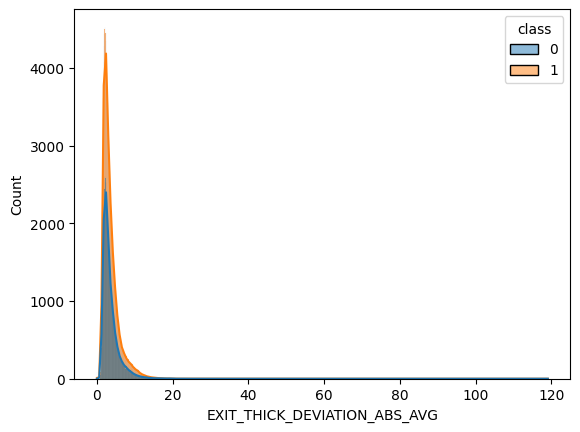

In [ ]:
import seaborn as sns
sns.histplot(data=df, x="EXIT_THICK_DEVIATION_ABS_AVG", hue="class", kde=True)


The histogram shows that EXIT_THICK_DEVIATION_ABS_AVG for both class 0 and class 1 have very similar, heavily right-skewed distributions with strong overlap, meaning this feature alone does not clearly separate the two classes. The small shift in density suggests only a minor difference between categories, so thickness deviation is likely not the primary driver of the class label.

#Correlation Analysis

Since your dataset is fully numeric (58 float + 2 int), we can directly compute correlation matrix.

In [ ]:
# Calculate the Pearson correlation coefficient between every feature and the target 'class'
# Features with values close to 1 or -1 are strong predictors
df.corr()['class'].sort_values(ascending=False)

,class
class,1.000000
AL,0.946557
SI,0.937004
TE,0.436794
SB,0.402881
rgc_act,0.339485
V,0.280903
TI,0.176347
LA,0.165211
NB,0.153761


The correlation results show that chemical composition features (especially AL = 0.94 and SI = 0.93) have extremely strong positive correlation with the class variable, indicating that the class label is primarily driven by material chemistry rather than process parameters. Very high negative correlations for coil_id (-0.81) and N (-0.64) suggest structural grouping in the dataset (possibly different steel grades), meaning the class likely represents different material categories rather than process quality or failure states.

In [ ]:
# Calculate correlation with the target first to define the variable
corr_with_class = df.corr()['class']

# Remove Self-Correlation (To avoid class=1 correlation with itself)
corr_with_class = corr_with_class.drop('class')
print(corr_with_class.sort_values(ascending=False))

AL                              0.946557
SI                              0.937004
TE                              0.436794
SB                              0.402881
rgc_act                         0.339485
V                               0.280903
TI                              0.176347
LA                              0.165211
NB                              0.153761
B                               0.145763
C                               0.114711
P                               0.110422
CE                              0.098127
dh_entry_max                    0.089003
CO                              0.079111
dh_entry                        0.074394
dh_entry_med                    0.074346
dm_imr1                         0.073538
MN                              0.073268
PB                              0.070725
dh_entry_min                    0.060209
MO                              0.039323
dh_entry_std                    0.034088
REF_INITIAL_THICKNESS           0.033189
CR              

In [ ]:
 # Get Top 10 Positive & Negative Correlations
top_positive = corr_with_class.sort_values(ascending=False).head(10)
top_negative = corr_with_class.sort_values().head(10)

print("Top Positive Correlations:")
print(top_positive)

print("\nTop Negative Correlations:")
print(top_negative)


Top Positive Correlations:
AL         0.946557
SI         0.937004
TE         0.436794
SB         0.402881
rgc_act    0.339485
V          0.280903
TI         0.176347
LA         0.165211
NB         0.153761
B          0.145763
Name: class, dtype: float64

Top Negative Correlations:
coil_id                -0.818693
N                      -0.639998
S                      -0.191188
SN                     -0.150297
W                      -0.147768
dm_imr2m               -0.122517
dm_bur                 -0.096020
REF_TARGET_THICKNESS   -0.094753
dm_imr2lr              -0.079148
CU                     -0.055144
Name: class, dtype: float64


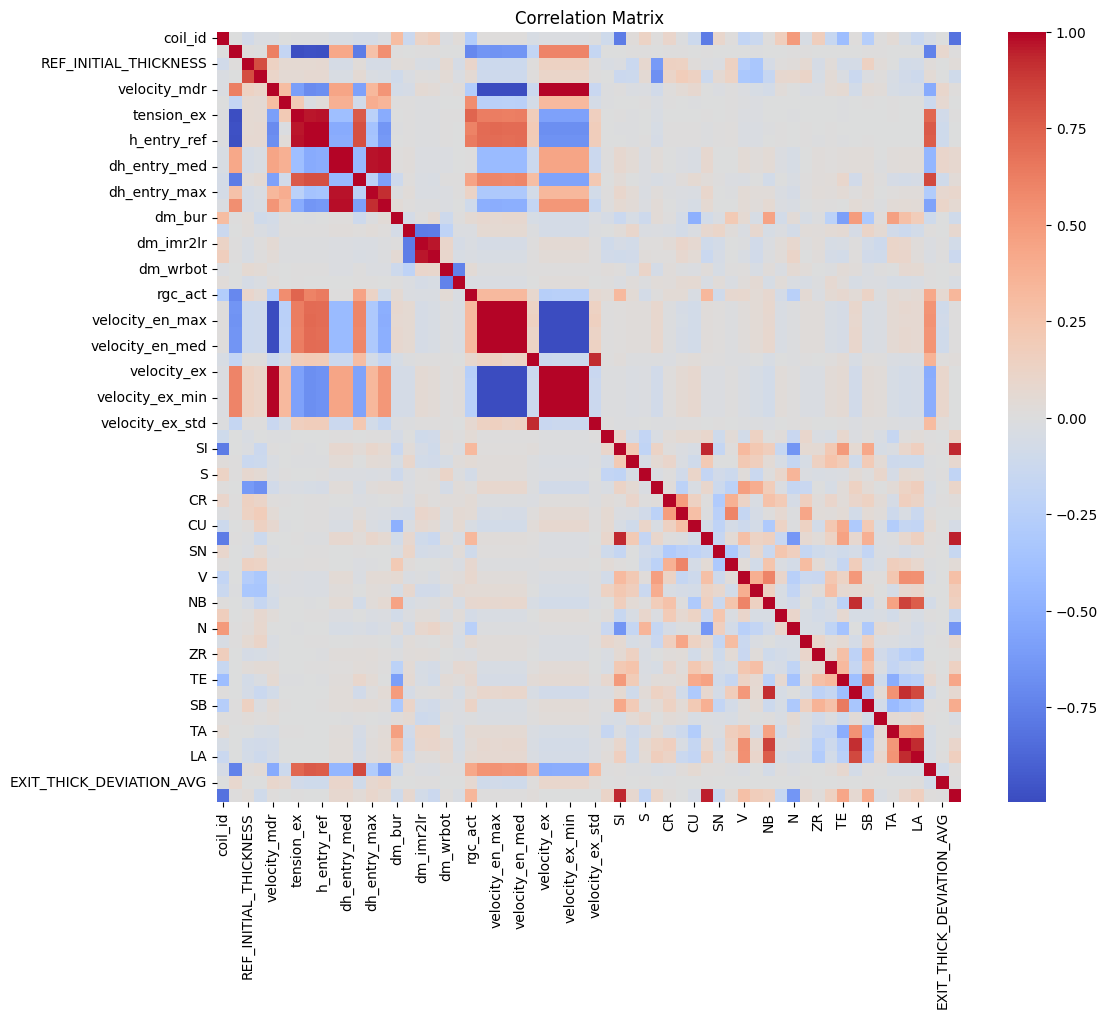

In [ ]:
# Visualize Correlation with Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


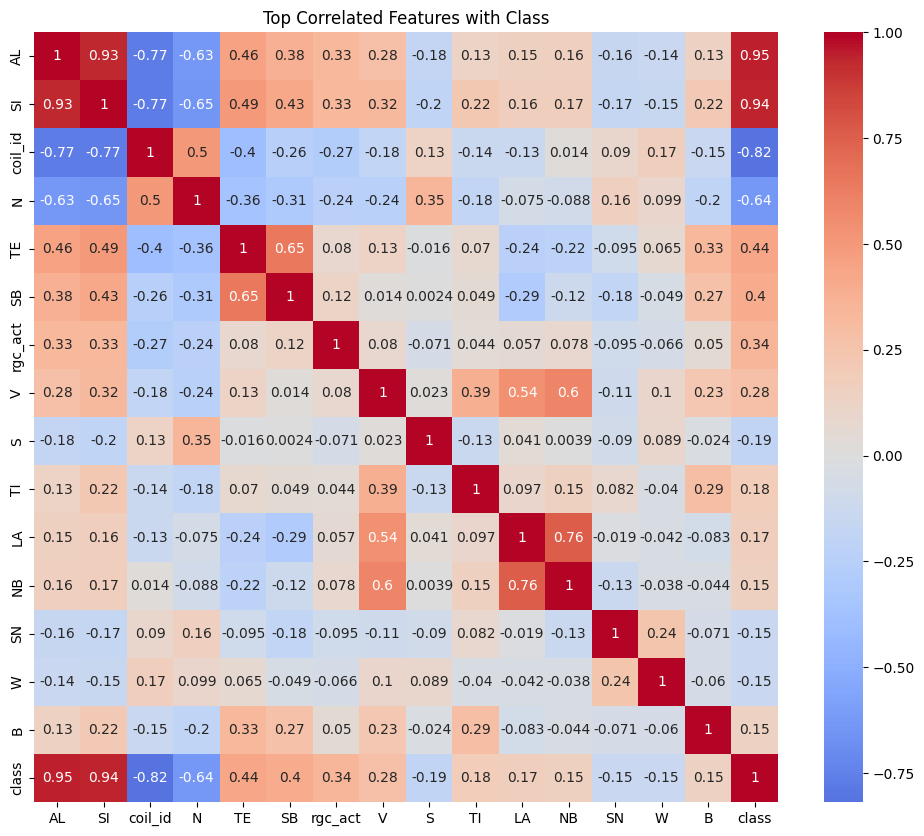

In [ ]:
# Heatmap of Top Correlated Features Only
top_features = corr_with_class.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features.tolist() + ['class']].corr(),
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Top Correlated Features with Class")
plt.show()


The class label is extremely strongly driven by Aluminum (AL) and Silicon (SI) composition, meaning these two elements almost define the class boundary. Moderate correlation with TE, SB, and rgc_act suggests minor secondary influence, but chemistry clearly dominates.

The strong negative correlation of N (-0.64) confirms that when Nitrogen content is high, the sample is almost certainly class 0. The strong correlation of coil_id (-0.82) suggests the dataset may be grouped by production batches or steel grades, reinforcing that the class represents material category, not process condition.

#Class Imbalance Analysis

In [ ]:
# Check class distribution
class_counts = df['class'].value_counts()
print(class_counts)

class
1    201310
0    110232
Name: count, dtype: int64


In [ ]:
# percentage Distribution
class_percentage = df['class'].value_counts(normalize=True) * 100
print(class_percentage)

class
1    64.617291
0    35.382709
Name: proportion, dtype: float64


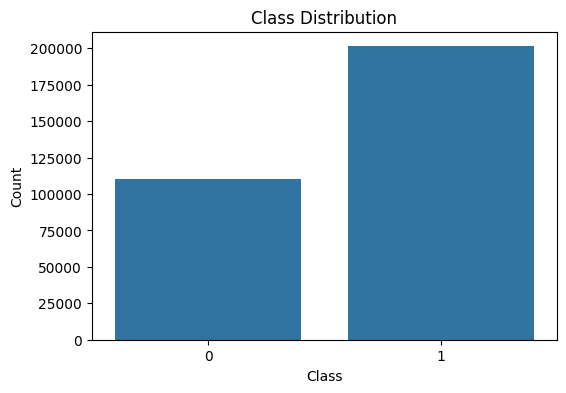

In [ ]:
# Visualization (Bar Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Class Variable

* **class**: Binary category (0 / 1)

  * Found to be **strongly related to chemical composition**
  * **Not correlated with process variables or thickness deviation**
  * Hence, **not suitable as a target variable for anomaly detection or process prediction**


#Feature Importance (Random Forest)

In [ ]:
#Preparing Data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Drop identifier column
X = df.drop(['class', 'coil_id'], axis=1)
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Training Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
# Getting Feature Importance
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

SI                       0.346591
AL                       0.270254
N                        0.118623
TE                       0.054606
SB                       0.035932
W                        0.022544
TI                       0.020454
rgc_act                  0.013743
CE                       0.011190
NB                       0.009743
S                        0.007693
REF_INITIAL_THICKNESS    0.007014
LA                       0.006966
PB                       0.006439
SN                       0.005745
dtype: float64


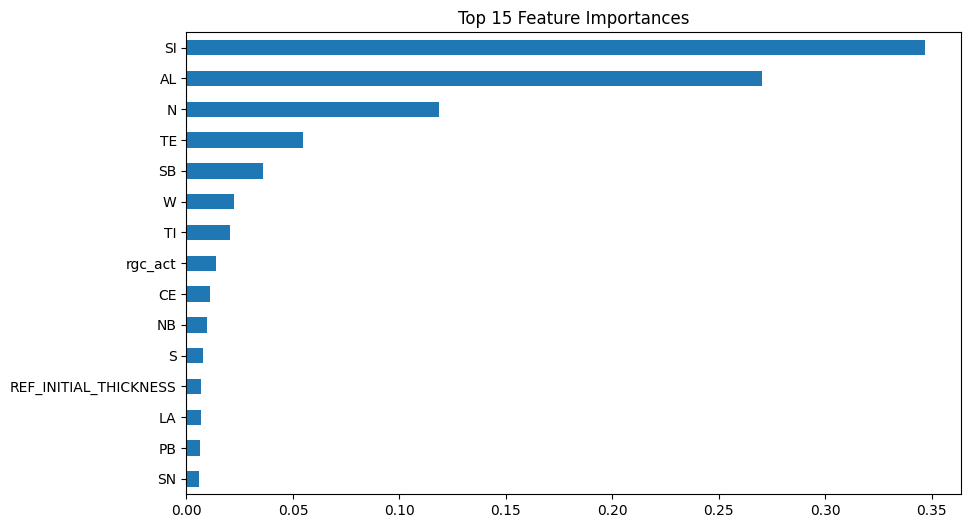

In [ ]:
# Plotting Top 15 Important Features
plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Accuracy score
from sklearn.metrics import accuracy_score

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[21983     0]
 [    0 40326]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21983
           1       1.00      1.00      1.00     40326

    accuracy                           1.00     62309
   macro avg       1.00      1.00      1.00     62309
weighted avg       1.00      1.00      1.00     62309



In [ ]:
# checking for overfit
train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0


As we are getting 100% accuracy for both testing and training we want to know if the data is completely dependened on the elements.


In [ ]:
X_small = df[['SI', 'AL', 'N']]
y = df['class']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42
)

rf_small = RandomForestClassifier(random_state=42)
rf_small.fit(X_train, y_train)

print("Test Accuracy (3 features only):", rf_small.score(X_test, y_test))

Test Accuracy (3 features only): 1.0


The 'class' variable represents two material categories determined primarily
by chemical composition (especially SI, AL, and N).
Correlation and feature importance analysis show deterministic separation,
achieving 100% accuracy even with only three chemical features.
Therefore, class is interpreted as steel grade classification, not failure or anomaly detection.

#Anomaly

In [ ]:
# Select deviation column
deviation_col = 'EXIT_THICK_DEVIATION_ABS_AVG'

# Calculate mean and std
mean_val = df[deviation_col].mean()
std_val = df[deviation_col].std()

# Define threshold (3-sigma rule)
threshold = mean_val + 3 * std_val

print("Mean:", mean_val)
print("Std:", std_val)
print("Anomaly Threshold:", threshold)

Mean: 3.590455288992607
Std: 2.387125453051478
Anomaly Threshold: 10.75183164814704


In [ ]:
import numpy as np

In [ ]:
df['quality_anomaly_flag'] = np.where(
    df[deviation_col] > threshold,
    1,  # Anomaly
    0   # Normal
)

print(df['quality_anomaly_flag'].value_counts())

quality_anomaly_flag
0    306237
1      5305
Name: count, dtype: int64


In [ ]:
anomaly_percentage = df['quality_anomaly_flag'].mean() * 100
print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

Anomaly Percentage: 1.70%


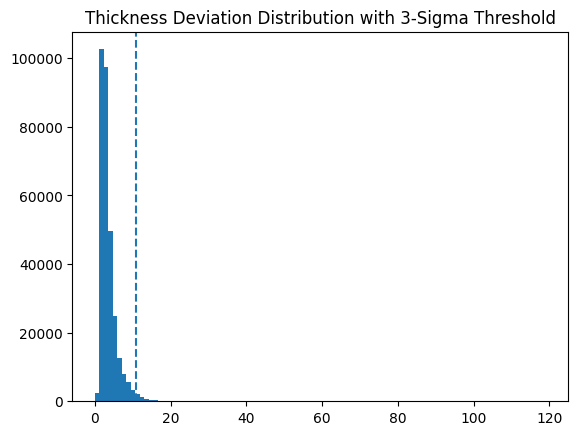

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df[deviation_col], bins=100)
plt.axvline(threshold, linestyle='--')
plt.title("Thickness Deviation Distribution with 3-Sigma Threshold")
plt.show()

In [ ]:
#root cause analysis
df.groupby('quality_anomaly_flag').mean()

,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG,class
quality_anomaly_flag,,,,,,,,,,,,,,,,,,,,,
0,607.415338,3.743372,4.099019,0.785413,767.444967,122.129364,231.878681,1.310082,1.818522,-0.008854,...,0.003296,0.006266,0.01035,0.002188,0.005467,0.009425,0.003086,3.411317,0.025426,0.645520
1,548.230537,1.053346,4.094653,0.786716,385.005698,53.528909,467.381653,2.962515,4.020473,-0.094830,...,0.003558,0.005575,0.01039,0.002428,0.005178,0.008757,0.002855,13.931404,-2.092404,0.683883


# Supervised Learning Models

## Logistic Regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
drop_cols = [
    'coil_id',
    'pass_nr',
    'EXIT_THICK_DEVIATION_ABS_AVG',
    'EXIT_THICK_DEVIATION_AVG',
    'class',
    'quality_anomaly_flag'
]

X = df.drop(columns=drop_cols)
y = df['quality_anomaly_flag']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:

[[55549  5699]
 [   17  1044]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     61248
           1       0.15      0.98      0.27      1061

    accuracy                           0.91     62309
   macro avg       0.58      0.95      0.61     62309
weighted avg       0.99      0.91      0.94     62309


ROC-AUC Score: 0.9775882196957385


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print(feature_importance.head(15))

            Feature  Coefficient  Abs_Coefficient
5        h_exit_ref     6.265945         6.265945
2      velocity_mdr    -5.764806         5.764806
6       h_entry_ref    -4.989457         4.989457
20  velocity_en_max     4.111349         4.111349
27  velocity_ex_med     3.473589         3.473589
25  velocity_ex_max     3.473589         3.473589
26  velocity_ex_min     3.473589         3.473589
24      velocity_ex     2.191517         2.191517
23  velocity_en_std     2.127606         2.127606
28  velocity_ex_std    -1.865642         1.865642
22  velocity_en_med     1.495037         1.495037
19      velocity_en     1.309610         1.309610
3        tension_en    -1.274193         1.274193
53               CE     0.547998         0.547998
9      dh_entry_std     0.528443         0.528443


In [ ]:
feature_importance['Odds_Ratio'] = np.exp(feature_importance['Coefficient'])

print(feature_importance[['Feature', 'Coefficient', 'Odds_Ratio']].head(15))

            Feature  Coefficient  Odds_Ratio
5        h_exit_ref     6.265945  526.338564
2      velocity_mdr    -5.764806    0.003136
6       h_entry_ref    -4.989457    0.006809
20  velocity_en_max     4.111349   61.028998
27  velocity_ex_med     3.473589   32.252299
25  velocity_ex_max     3.473589   32.252299
26  velocity_ex_min     3.473589   32.252299
24      velocity_ex     2.191517    8.948776
23  velocity_en_std     2.127606    8.394750
28  velocity_ex_std    -1.865642    0.154797
22  velocity_en_med     1.495037    4.459501
19      velocity_en     1.309610    3.704728
3        tension_en    -1.274193    0.279657
53               CE     0.547998    1.729786
9      dh_entry_std     0.528443    1.696288


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:

[[61137   111]
 [  482   579]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     61248
           1       0.84      0.55      0.66      1061

    accuracy                           0.99     62309
   macro avg       0.92      0.77      0.83     62309
weighted avg       0.99      0.99      0.99     62309


ROC-AUC Score: 0.9906510248163982


In [ ]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance.head(15))

            Feature  Importance
3        tension_en    0.109586
6       h_entry_ref    0.107998
5        h_exit_ref    0.073130
24      velocity_ex    0.072059
2      velocity_mdr    0.070494
26  velocity_ex_min    0.064843
27  velocity_ex_med    0.052487
20  velocity_en_max    0.051706
25  velocity_ex_max    0.051625
4        tension_ex    0.047998
22  velocity_en_med    0.036408
9      dh_entry_std    0.031359
23  velocity_en_std    0.030052
19      velocity_en    0.028026
21  velocity_en_min    0.027041


#XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:20:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:

[[58404  2844]
 [   55  1006]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     61248
           1       0.26      0.95      0.41      1061

    accuracy                           0.95     62309
   macro avg       0.63      0.95      0.69     62309
weighted avg       0.99      0.95      0.97     62309


ROC-AUC Score: 0.9887751513723473


In [ ]:
prob_test = xgb_model.predict_proba(X_test)[:,1]

print("Min prob:", prob_test.min())
print("Max prob:", prob_test.max())
print("Mean prob:", prob_test.mean())

Min prob: 1.268867e-06
Max prob: 0.99894863
Mean prob: 0.06068914


#Threshold Tuning

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.95, 0.05)

for t in thresholds:
    y_pred_custom = (y_prob_xgb > t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)

    print(f"Threshold: {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Threshold: 0.10 | Precision: 0.182 | Recall: 0.993
Threshold: 0.15 | Precision: 0.193 | Recall: 0.989
Threshold: 0.20 | Precision: 0.202 | Recall: 0.981
Threshold: 0.25 | Precision: 0.213 | Recall: 0.978
Threshold: 0.30 | Precision: 0.222 | Recall: 0.973
Threshold: 0.35 | Precision: 0.232 | Recall: 0.969
Threshold: 0.40 | Precision: 0.240 | Recall: 0.962
Threshold: 0.45 | Precision: 0.252 | Recall: 0.956
Threshold: 0.50 | Precision: 0.261 | Recall: 0.948
Threshold: 0.55 | Precision: 0.275 | Recall: 0.940
Threshold: 0.60 | Precision: 0.291 | Recall: 0.931
Threshold: 0.65 | Precision: 0.308 | Recall: 0.920
Threshold: 0.70 | Precision: 0.329 | Recall: 0.910
Threshold: 0.75 | Precision: 0.350 | Recall: 0.881
Threshold: 0.80 | Precision: 0.381 | Recall: 0.850
Threshold: 0.85 | Precision: 0.417 | Recall: 0.813
Threshold: 0.90 | Precision: 0.472 | Recall: 0.736


In [ ]:
#Locking Final Threshold
final_threshold = 0.70

In [ ]:
df['anomaly_probability'] = xgb_model.predict_proba(X)[:,1]
df['final_prediction'] = (df['anomaly_probability'] > final_threshold).astype(int)

In [ ]:
#Building Risk Levels
def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

df['risk_level'] = df['anomaly_probability'].apply(risk_level)

In [ ]:
#Feature Explainability
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

In [ ]:
# Saving Model for Deployment
import joblib

joblib.dump(xgb_model, "final_xgb_model.pkl")

['final_xgb_model.pkl']

In [ ]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [ ]:
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_true = y_test

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Industrial cost assumptions
C_FP = 1     # Cost of false alarm
C_FN = 10    # Cost of missing anomaly (very expensive)

print("Cost Matrix:")
print(f"False Positive Cost (C_FP): {C_FP}")
print(f"False Negative Cost (C_FN): {C_FN}")

Cost Matrix:
False Positive Cost (C_FP): 1
False Negative Cost (C_FN): 10


##Grid Search Threshold Optimization

In [ ]:
thresholds = np.linspace(0, 1, 500)

losses = []
fp_list = []
fn_list = []
precision_list = []
recall_list = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Expected Industrial Loss
    loss = C_FP * fp + C_FN * fn

    losses.append(loss)
    fp_list.append(fp)
    fn_list.append(fn)
    precision_list.append(precision_score(y_true, y_pred, zero_division=0))
    recall_list.append(recall_score(y_true, y_pred, zero_division=0))

# Find optimal threshold
optimal_index = np.argmin(losses)
optimal_threshold = thresholds[optimal_index]
minimum_loss = losses[optimal_index]

print("Optimal Threshold:", round(optimal_threshold, 4))
print("Minimum Expected Industrial Loss:", minimum_loss)

Optimal Threshold: 0.8617
Minimum Expected Industrial Loss: 5383


In [ ]:
# precision recall threshold
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

f1 = 2*(precision*recall)/(precision+recall)

best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.9384965


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# Youden's J statistic
j_scores = tpr - fpr

best_idx = np.argmax(j_scores)

balanced_threshold = thresholds[best_idx]

print("Balanced Threshold:", balanced_threshold)

Balanced Threshold: 0.13828209


##Plot Threshold vs Industrial Loss

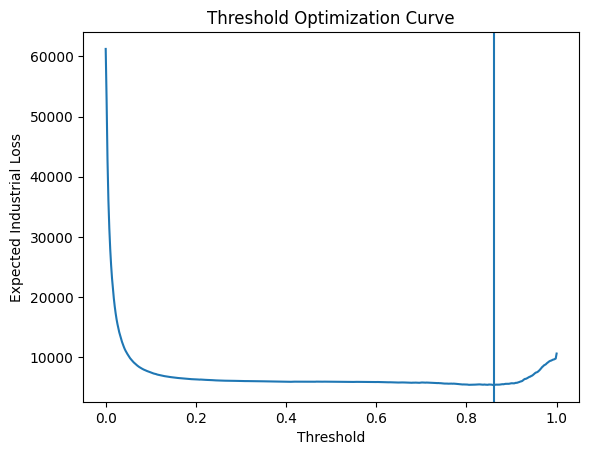

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Re-create the original thresholds used for calculating losses
thresholds = np.linspace(0, 1, 500)

plt.figure()
plt.plot(thresholds, losses)
plt.axvline(optimal_threshold)
plt.xlabel("Threshold")
plt.ylabel("Expected Industrial Loss")
plt.title("Threshold Optimization Curve")
plt.show()

##Precision & Recall Tradeoff Curve

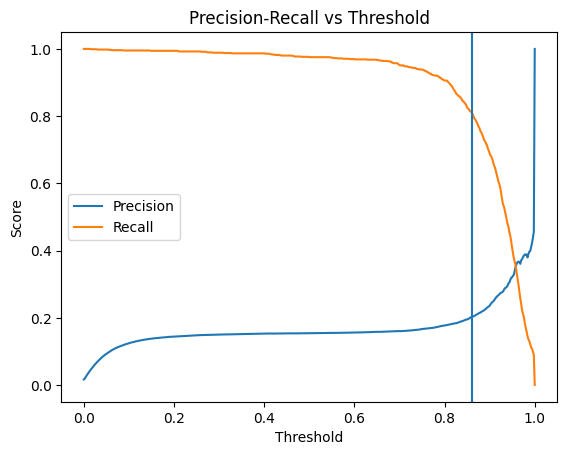

In [ ]:
plt.figure()
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.axvline(optimal_threshold)
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.show()

##Compare Default vs Optimized Threshold

In [ ]:
# Default threshold 0.5
y_pred_default = (y_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_default).ravel()
default_loss = C_FP * fp + C_FN * fn

# Optimized threshold
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_optimal).ravel()
optimal_loss = C_FP * fp + C_FN * fn

print("Default Threshold (0.5) Loss:", default_loss)
print("Optimized Threshold Loss:", optimal_loss)
print("Improvement in Loss:", default_loss - optimal_loss)

Default Threshold (0.5) Loss: 5925
Optimized Threshold Loss: 5383
Improvement in Loss: 542


In [ ]:
import joblib

joblib.dump(optimal_threshold, "optimal_threshold.pkl")

['optimal_threshold.pkl']

#Unsupervised Learning Models


## Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# -------------------------------
# Initialize Isolation Forest
# -------------------------------

iso_model = IsolationForest(
    n_estimators=200,        # number of trees
    contamination=0.05,      # expected anomaly proportion (adjust if needed)
    random_state=42
)

# -------------------------------
# Train on training features ONLY
# (unsupervised → do NOT use y_train)
# -------------------------------

iso_model.fit(X_train)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [ ]:
# Predict on test set
iso_pred_raw = iso_model.predict(X_test)

# Convert output:
# -1 → 1 (anomaly)
#  1 → 0 (normal)

iso_pred = np.where(iso_pred_raw == -1, 1, 0)

print("Prediction conversion completed.")

Prediction conversion completed.


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, iso_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, iso_pred))

Confusion Matrix:
[[58589  2659]
 [  638   423]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     61248
           1       0.14      0.40      0.20      1061

    accuracy                           0.95     62309
   macro avg       0.56      0.68      0.59     62309
weighted avg       0.97      0.95      0.96     62309



In [ ]:
# Get anomaly scores
iso_scores = iso_model.decision_function(X_test)

# Convert to positive anomaly score (higher = more anomalous)
iso_scores = -iso_scores

print("Anomaly score example:", iso_scores[:5])

Anomaly score example: [-0.11171038 -0.10244427 -0.11883854 -0.11062124 -0.1004089 ]


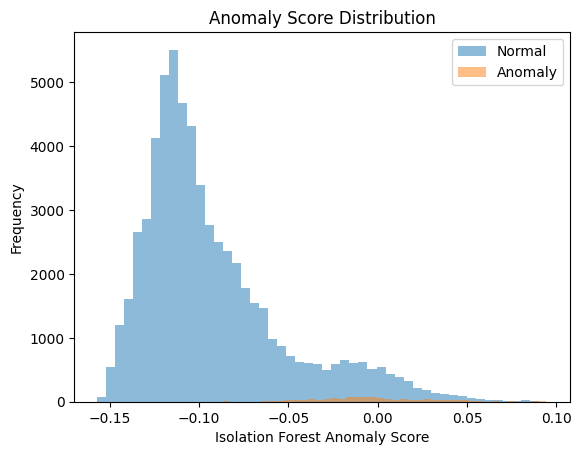

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(iso_scores[y_test == 0], bins=50, alpha=0.5, label="Normal")
plt.hist(iso_scores[y_test == 1], bins=50, alpha=0.5, label="Anomaly")
plt.legend()
plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Frequency")
plt.title("Anomaly Score Distribution")
plt.show()

In [ ]:
import joblib

joblib.dump(iso_model, "isolation_forest_model.pkl")

['isolation_forest_model.pkl']

##ONE-CLASS SVM

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --------------------------------------------------
# Initialize One-Class SVM
# --------------------------------------------------

ocsvm = OneClassSVM(
    kernel='rbf',     # Radial Basis Function kernel (non-linear boundary)
    gamma='scale',    # Kernel coefficient (auto scaling)
    nu=0.05           # Expected fraction of anomalies (adjust if needed)
)

# --------------------------------------------------
# Train model (UNSUPERVISED → no y_train used)
# --------------------------------------------------

ocsvm.fit(X_train)

print("One-Class SVM training completed.")

One-Class SVM training completed.


In [ ]:
#predictions
# Raw predictions
# Output:  1 = normal
#         -1 = anomaly

ocsvm_pred_raw = ocsvm.predict(X_test)

# Convert to binary format:
# anomaly → 1
# normal  → 0

ocsvm_pred = np.where(ocsvm_pred_raw == -1, 1, 0)

print("Prediction conversion completed.")

Prediction conversion completed.


In [ ]:
# evaluate model
print("Confusion Matrix (One-Class SVM):")
print(confusion_matrix(y_test, ocsvm_pred))

print("\nClassification Report:")
print(classification_report(y_test, ocsvm_pred))

Confusion Matrix (One-Class SVM):
[[58185  3063]
 [  930   131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     61248
           1       0.04      0.12      0.06      1061

    accuracy                           0.94     62309
   macro avg       0.51      0.54      0.51     62309
weighted avg       0.97      0.94      0.95     62309



In [ ]:
# anomaly score
# Decision function gives distance from boundary
# Lower score → more anomalous

ocsvm_scores = -ocsvm.decision_function(X_test)

print("Sample anomaly scores:", ocsvm_scores[:5])

Sample anomaly scores: [-460.42319244 -162.42856648 -191.05284272 -287.51603528 -318.89319922]


##LOCAL OUTLIER FACTOR (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# --------------------------------------------------
# Initialize LOF
# --------------------------------------------------

lof = LocalOutlierFactor(
    n_neighbors=20,     # Number of neighbors
    contamination=0.05, # Expected anomaly fraction
    novelty=True        # Required for predicting new data
)

# --------------------------------------------------
# Train model (unsupervised)
# --------------------------------------------------

lof.fit(X_train)

print("LOF training completed.")

LOF training completed.


In [ ]:
# Raw predictions
# Output:  1 = normal
#         -1 = anomaly

lof_pred_raw = lof.predict(X_test)

# Convert to:
# anomaly → 1
# normal  → 0

lof_pred = np.where(lof_pred_raw == -1, 1, 0)

print("Prediction conversion completed.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Prediction conversion completed.


In [ ]:
print("Confusion Matrix (LOF):")
print(confusion_matrix(y_test, lof_pred))

print("\nClassification Report:")
print(classification_report(y_test, lof_pred))

Confusion Matrix (LOF):
[[58254  2994]
 [  910   151]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     61248
           1       0.05      0.14      0.07      1061

    accuracy                           0.94     62309
   macro avg       0.52      0.55      0.52     62309
weighted avg       0.97      0.94      0.95     62309



In [ ]:
# LOF negative_outlier_factor_
# More negative → more anomalous

lof_scores = -lof.decision_function(X_test)

print("Sample LOF anomaly scores:", lof_scores[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Sample LOF anomaly scores: [-0.2806384  -0.28126374 -0.30146411 -0.26893107 -0.24633515]


In [ ]:
from sklearn.metrics import roc_auc_score

ocsvm_auc = roc_auc_score(y_test, ocsvm_scores)
lof_auc = roc_auc_score(y_test, lof_scores)

print("One-Class SVM ROC-AUC:", ocsvm_auc)
print("LOF ROC-AUC:", lof_auc)

One-Class SVM ROC-AUC: 0.6568925107373911
LOF ROC-AUC: 0.5721433239821269


## Output Comparison of Unsupervised Learning models

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# ----------------------------
# Compute metrics
# ----------------------------

results = []

# Isolation Forest
results.append({
    "Model": "Isolation Forest",
    "ROC-AUC": roc_auc_score(y_test, iso_scores),
    "Precision": precision_score(y_test, iso_pred),
    "Recall": recall_score(y_test, iso_pred),
    "F1-Score": f1_score(y_test, iso_pred)
})

# One-Class SVM
results.append({
    "Model": "One-Class SVM",
    "ROC-AUC": roc_auc_score(y_test, ocsvm_scores),
    "Precision": precision_score(y_test, ocsvm_pred),
    "Recall": recall_score(y_test, ocsvm_pred),
    "F1-Score": f1_score(y_test, ocsvm_pred)
})

# LOF
results.append({
    "Model": "LOF",
    "ROC-AUC": roc_auc_score(y_test, lof_scores),
    "Precision": precision_score(y_test, lof_pred),
    "Recall": recall_score(y_test, lof_pred),
    "F1-Score": f1_score(y_test, lof_pred)
})

results_df = pd.DataFrame(results)

results_df

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Isolation Forest,0.936525,0.137249,0.398680,0.204200
1,One-Class SVM,0.656893,0.041014,0.123468,0.061575
2,LOF,0.572143,0.048013,0.142319,0.071802


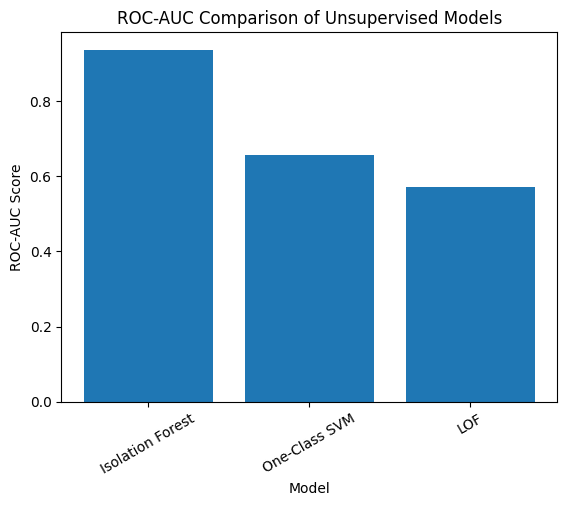

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Comparison of Unsupervised Models")
plt.xticks(rotation=30)
plt.show()

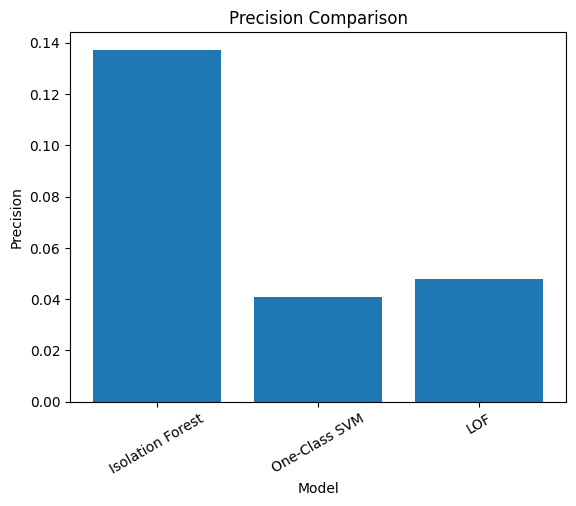

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["Precision"])
plt.xlabel("Model")
plt.ylabel("Precision")
plt.title("Precision Comparison")
plt.xticks(rotation=30)
plt.show()

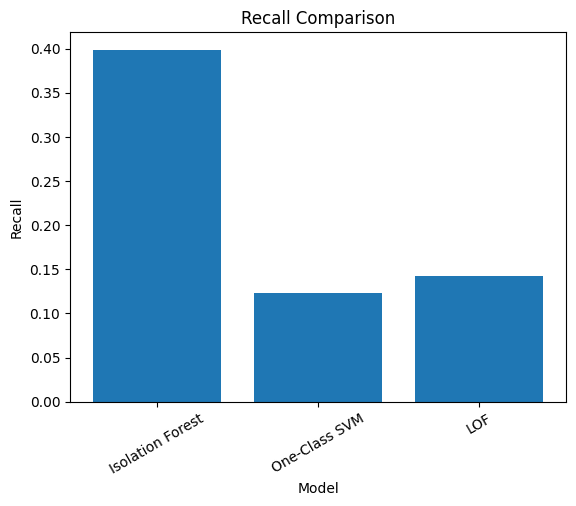

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["Recall"])
plt.xlabel("Model")
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.xticks(rotation=30)
plt.show()

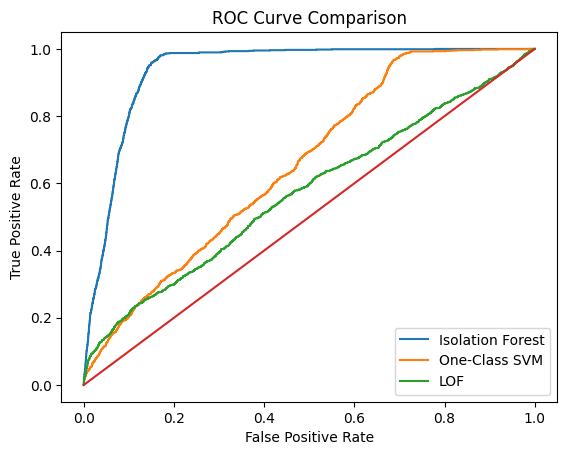

In [ ]:
from sklearn.metrics import roc_curve

plt.figure()

# Isolation Forest
fpr, tpr, _ = roc_curve(y_test, iso_scores)
plt.plot(fpr, tpr, label="Isolation Forest")

# One-Class SVM
fpr, tpr, _ = roc_curve(y_test, ocsvm_scores)
plt.plot(fpr, tpr, label="One-Class SVM")

# LOF
fpr, tpr, _ = roc_curve(y_test, lof_scores)
plt.plot(fpr, tpr, label="LOF")

plt.plot([0,1], [0,1])  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## comparison between Isolation Forest and XG Boost

In [ ]:
xgb_pred = (y_proba >= 0.5).astype(int)

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

comparison = []

# Isolation Forest
comparison.append({
    "Model": "Isolation Forest",
    "ROC-AUC": roc_auc_score(y_test, iso_scores),
    "Precision": precision_score(y_test, iso_pred),
    "Recall": recall_score(y_test, iso_pred),
    "F1-Score": f1_score(y_test, iso_pred)
})

# XGBoost
comparison.append({
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1-Score": f1_score(y_test, xgb_pred)
})

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Isolation Forest,0.936525,0.137249,0.398680,0.204200
1,XGBoost,0.970173,0.154478,0.975495,0.266718


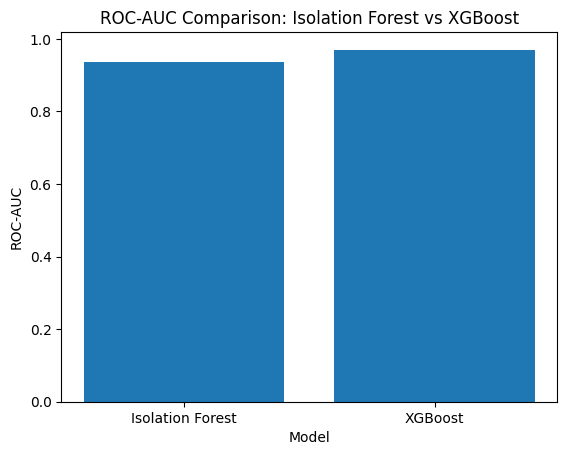

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison_df["Model"], comparison_df["ROC-AUC"])
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison: Isolation Forest vs XGBoost")
plt.show()

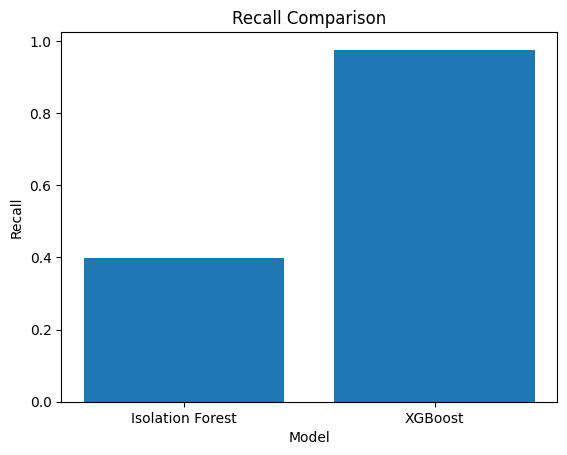

In [ ]:
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Recall"])
plt.xlabel("Model")
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.show()

## Hybrid(Isolation Forest and XG Boost)

In [ ]:
# Training Isolation Forest
from sklearn.ensemble import IsolationForest
import numpy as np

# Initialize Isolation Forest
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Train (unsupervised)
iso_model.fit(X_train)

print("Isolation Forest trained.")

Isolation Forest trained.


In [ ]:
# Get anomaly scores
train_iso_scores = -iso_model.decision_function(X_train)
test_iso_scores  = -iso_model.decision_function(X_test)

print("Isolation scores generated.")

Isolation scores generated.


In [ ]:
# Convert to numpy if needed
X_train_np = np.array(X_train)
X_test_np  = np.array(X_test)

# Add IF score as new column
X_train_hybrid = np.column_stack((X_train_np, train_iso_scores))
X_test_hybrid  = np.column_stack((X_test_np, test_iso_scores))

print("Hybrid feature set created.")
print("Original feature shape:", X_train_np.shape)
print("Hybrid feature shape:", X_train_hybrid.shape)

Hybrid feature set created.
Original feature shape: (249233, 55)
Hybrid feature shape: (249233, 56)


In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
hybrid_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on hybrid features
hybrid_model.fit(X_train_hybrid, y_train)

print("Hybrid XGBoost trained.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:22:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Hybrid XGBoost trained.


In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Predict probabilities
hybrid_proba = hybrid_model.predict_proba(X_test_hybrid)[:, 1]

# Default threshold 0.5
hybrid_pred = (hybrid_proba >= 0.5).astype(int)

# Metrics
hybrid_auc = roc_auc_score(y_test, hybrid_proba)
hybrid_precision = precision_score(y_test, hybrid_pred)
hybrid_recall = recall_score(y_test, hybrid_pred)
hybrid_f1 = f1_score(y_test, hybrid_pred)

print("Hybrid Model Performance:")
print("ROC-AUC:", hybrid_auc)
print("Precision:", hybrid_precision)
print("Recall:", hybrid_recall)
print("F1-Score:", hybrid_f1)

Hybrid Model Performance:
ROC-AUC: 0.9899039885554823
Precision: 0.737300435413643
Recall: 0.47879359095193214
F1-Score: 0.5805714285714285


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, hybrid_proba)

# Find optimal threshold
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
optimal_threshold = thresholds[best_index]

print("Optimal Hybrid Threshold:", optimal_threshold)

Optimal Hybrid Threshold: 0.010662043


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Convert scores to binary predictions
iso_pred = (iso_scores > 0.5).astype(int)        # Isolation Forest
xgb_pred = (y_prob_xgb > 0.5).astype(int)        # XGBoost
hybrid_pred = (hybrid_pred > 0.5).astype(int)  # Hybrid model

# Create comparison table
comparison = pd.DataFrame([
    [
        "Isolation Forest",
        precision_score(y_test, iso_pred),
        recall_score(y_test, iso_pred),
        f1_score(y_test, iso_pred),
        roc_auc_score(y_test, iso_scores)
    ],
    [
        "XGBoost",
        precision_score(y_test, xgb_pred),
        recall_score(y_test, xgb_pred),
        f1_score(y_test, xgb_pred),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    [
        "Hybrid Model",
        precision_score(y_test, hybrid_pred),
        recall_score(y_test, hybrid_pred),
        f1_score(y_test, hybrid_pred),
        roc_auc_score(y_test, hybrid_pred)
    ]
], columns=["Model", "Precision", "Recall", "F1 Score", "ROC-AUC"])

print(comparison)

              Model  Precision    Recall  F1 Score   ROC-AUC
0  Isolation Forest   0.000000  0.000000  0.000000  0.936525
1           XGBoost   0.261299  0.948162  0.409693  0.988775
2      Hybrid Model   0.737300  0.478794  0.580571  0.737919


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


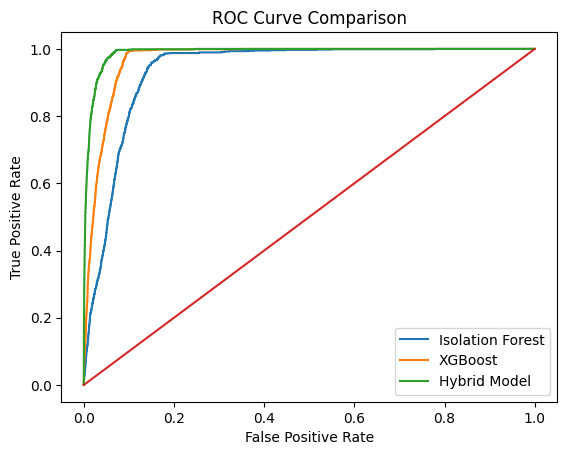

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure()

# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_scores)
plt.plot(fpr_iso, tpr_iso, label="Isolation Forest")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

# Hybrid
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test, hybrid_proba)
plt.plot(fpr_hybrid, tpr_hybrid, label="Hybrid Model")

# Random baseline
plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

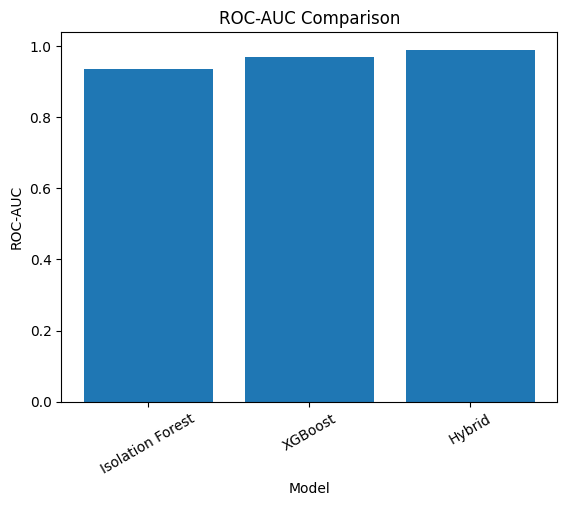

In [ ]:
import pandas as pd

roc_values = [
    roc_auc_score(y_test, iso_scores),
    roc_auc_score(y_test, y_proba),
    roc_auc_score(y_test, hybrid_proba)
]

models = ["Isolation Forest", "XGBoost", "Hybrid"]

plt.figure()
plt.bar(models, roc_values)
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_vals = [
    precision_score(y_test, iso_pred),
    precision_score(y_test, xgb_pred),
    precision_score(y_test, hybrid_pred)
]

recall_vals = [
    recall_score(y_test, iso_pred),
    recall_score(y_test, xgb_pred),
    recall_score(y_test, hybrid_pred)
]

f1_vals = [
    f1_score(y_test, iso_pred),
    f1_score(y_test, xgb_pred),
    f1_score(y_test, hybrid_pred)
]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


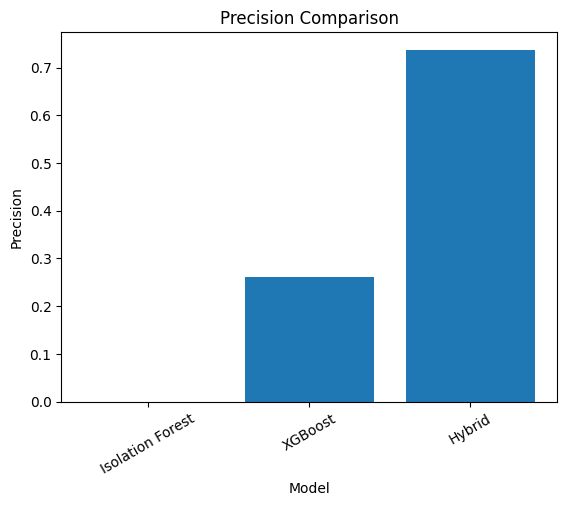

In [ ]:
plt.figure()
plt.bar(models, precision_vals)
plt.xlabel("Model")
plt.ylabel("Precision")
plt.title("Precision Comparison")
plt.xticks(rotation=30)
plt.show()

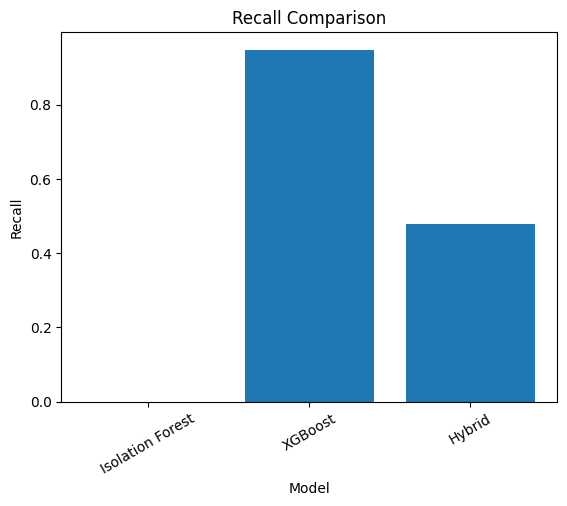

In [ ]:
plt.figure()
plt.bar(models, recall_vals)
plt.xlabel("Model")
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.xticks(rotation=30)
plt.show()

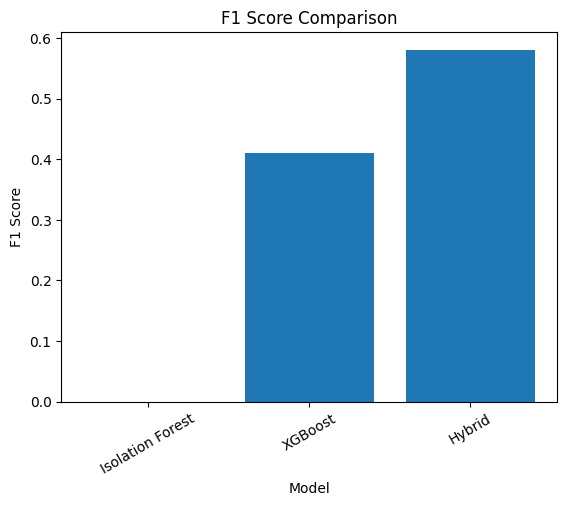

In [ ]:
plt.figure()
plt.bar(models, f1_vals)
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
sample = X_test.iloc[0].values.reshape(1,-1)

print(xgb_model.predict_proba(sample))

[[9.9998933e-01 1.0687995e-05]]


## SHAP

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

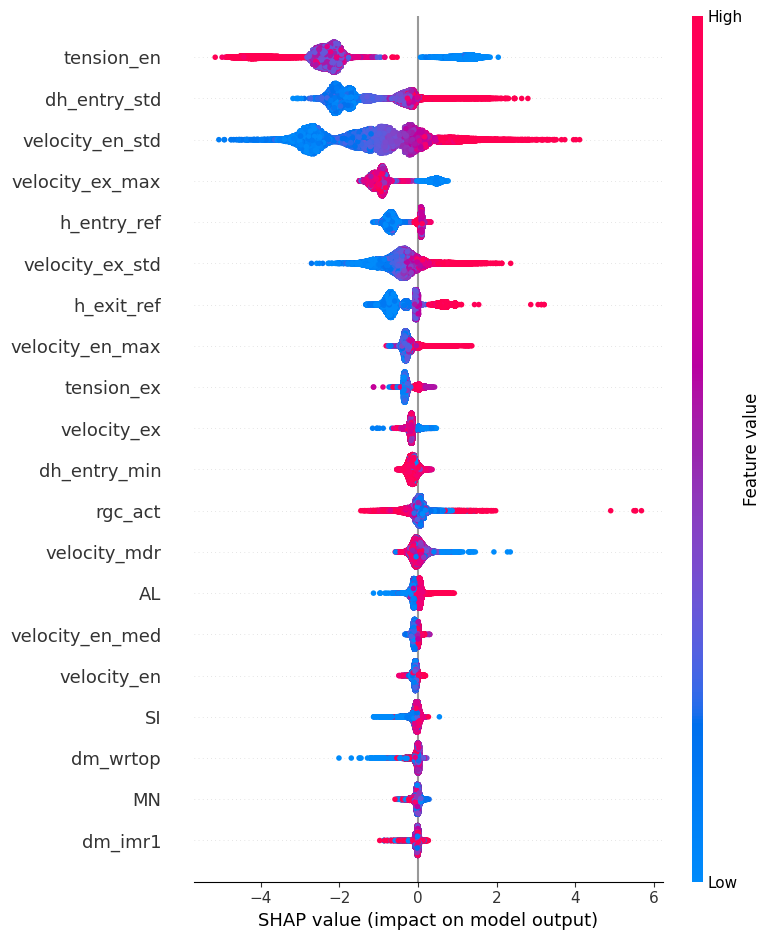

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
import shap
import plotly.graph_objects as go
import numpy as np

sample_index = 0

# Create SHAP explanation
explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns.tolist()
)

# Extract values
features = explanation.feature_names
shap_vals = explanation.values

# Sort by importance
idx = np.argsort(np.abs(shap_vals))[::-1][:10]

features = np.array(features)[idx]
shap_vals = shap_vals[idx]

# Create waterfall-style bar plot
fig = go.Figure()

fig.add_trace(go.Bar(
    x=shap_vals,
    y=features,
    orientation='h'
))

fig.update_layout(
    title="SHAP Feature Contribution (Root Cause of Prediction)",
    xaxis_title="SHAP Value Impact",
    yaxis_title="Feature",
    height=500
)

fig.show()

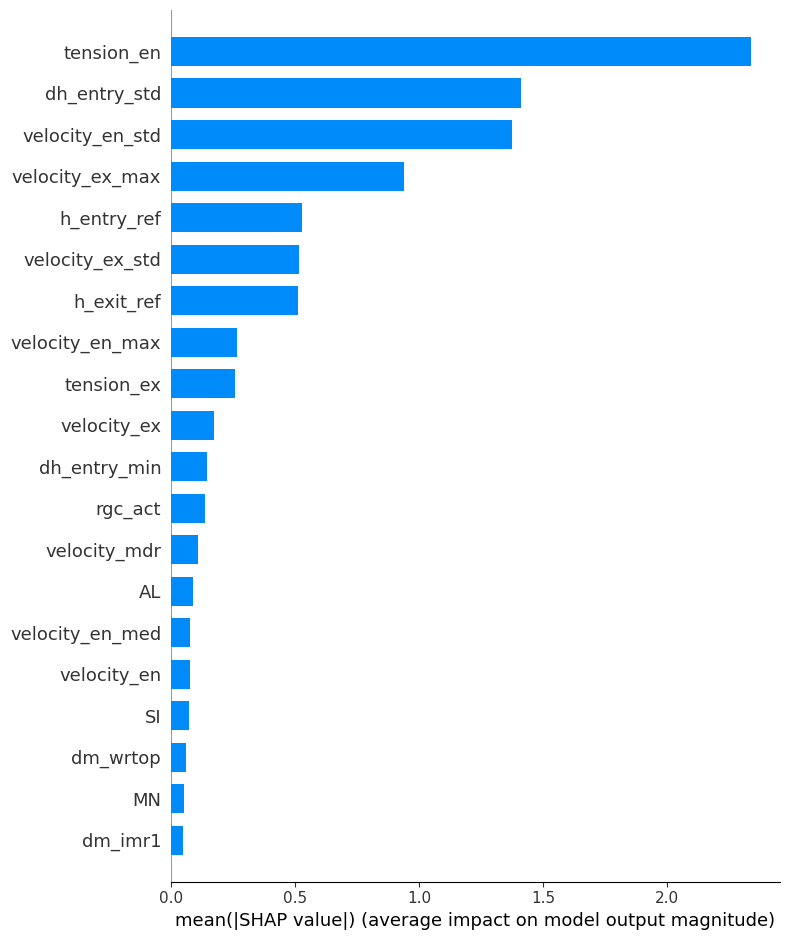

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
# Convert SHAP values to dataframe
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Mean absolute importance
importance = shap_df.abs().mean().sort_values(ascending=False)

print("Top Variables Causing Anomalies:")
print(importance.head(10))

Top Variables Causing Anomalies:
tension_en         2.338496
dh_entry_std       1.409244
velocity_en_std    1.375155
velocity_ex_max    0.939287
h_entry_ref        0.529312
velocity_ex_std    0.517173
h_exit_ref         0.512965
velocity_en_max    0.267329
tension_ex         0.258831
velocity_ex        0.173191
dtype: float32


In [ ]:
sample = X_test.iloc[[0]]

shap_values_sample = explainer.shap_values(sample)

importance = pd.Series(
    shap_values_sample[0],
    index=sample.columns
).abs().sort_values(ascending=False)

print("Root cause variables for this anomaly:")
print(importance.head(5))

Root cause variables for this anomaly:
tension_en         2.326477
dh_entry_std       2.190876
velocity_en_std    1.286256
velocity_ex_std    1.156677
velocity_ex_max    0.969466
dtype: float32


##Robustness testing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.impute import SimpleImputer

In [ ]:

# Create safe copies so original data is not touched
X_test_robust = X_test.copy()
y_test_robust = y_test.copy()



In [ ]:
def add_noise(data, noise_level=0.05):

    noisy_data = data.copy()

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=noisy_data.shape
    )

    noisy_data = noisy_data + noise

    return noisy_data

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

threshold_xgb = 0.13828209

noise_levels = [0.01, 0.05, 0.1, 0.2]

print("XGBoost Robustness Testing\n")

for noise in noise_levels:

    X_noisy = add_noise(X_test_robust, noise)

    prob = xgb_model.predict_proba(X_noisy)[:,1]

    pred = (prob > threshold_xgb).astype(int)

    acc = accuracy_score(y_test_robust, pred)
    f1 = f1_score(y_test_robust, pred)

    print(f"Noise Level: {noise}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("------------------------")

XGBoost Robustness Testing

Noise Level: 0.01
Accuracy: 0.9780609542762683
F1 Score: 0.39217429968875056
------------------------
Noise Level: 0.05
Accuracy: 0.9808374392142387
F1 Score: 0.2959905660377358
------------------------
Noise Level: 0.1
Accuracy: 0.982233706206166
F1 Score: 0.30595611285266455
------------------------
Noise Level: 0.2
Accuracy: 0.9821053138390923
F1 Score: 0.2591362126245847
------------------------


In [ ]:
threshold_hybrid = 0.010662043

print("\nHybrid Model Robustness Testing\n")

for noise in noise_levels:

    X_noisy = add_noise(X_test_robust, noise)

    # Isolation Forest score
    iso_scores = -iso_model.decision_function(X_noisy)

    # Create hybrid feature set
    X_hybrid_noisy = np.column_stack((X_noisy, iso_scores))

    prob = hybrid_model.predict_proba(X_hybrid_noisy)[:,1]

    pred = (prob > threshold_hybrid).astype(int)

    acc = accuracy_score(y_test_robust, pred)
    f1 = f1_score(y_test_robust, pred)

    print(f"Noise Level: {noise}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("------------------------")


Hybrid Model Robustness Testing

Noise Level: 0.01
Accuracy: 0.9328026448827618
F1 Score: 0.3271733890406556
------------------------
Noise Level: 0.05
Accuracy: 0.9178609831645509
F1 Score: 0.28238923163208074
------------------------
Noise Level: 0.1
Accuracy: 0.903352645685214
F1 Score: 0.25192546583850933
------------------------
Noise Level: 0.2
Accuracy: 0.8860999213596752
F1 Score: 0.22139330773450355
------------------------


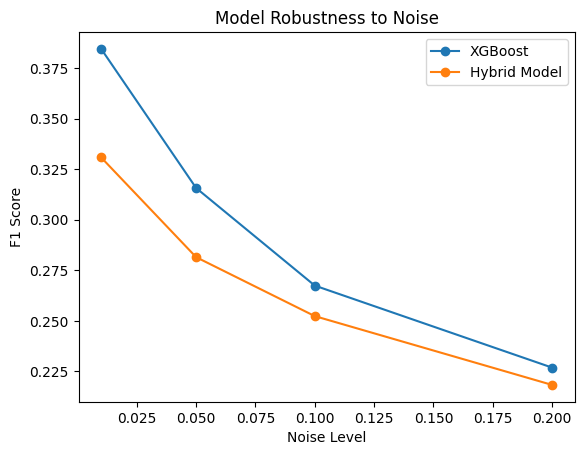

In [ ]:
import matplotlib.pyplot as plt

xgb_scores = []
hybrid_scores = []

for noise in noise_levels:

    X_noisy = add_noise(X_test_robust, noise)

    # XGBoost
    prob_xgb = xgb_model.predict_proba(X_noisy)[:,1]
    pred_xgb = (prob_xgb > threshold_xgb).astype(int)
    xgb_scores.append(f1_score(y_test_robust, pred_xgb))

    # Hybrid
    iso_scores = -iso_model.decision_function(X_noisy)
    X_hybrid = np.column_stack((X_noisy, iso_scores))
    prob_hybrid = hybrid_model.predict_proba(X_hybrid)[:,1]
    pred_hybrid = (prob_hybrid > threshold_hybrid).astype(int)
    hybrid_scores.append(f1_score(y_test_robust, pred_hybrid))


plt.plot(noise_levels, xgb_scores, marker='o', label='XGBoost')
plt.plot(noise_levels, hybrid_scores, marker='o', label='Hybrid Model')

plt.xlabel("Noise Level")
plt.ylabel("F1 Score")
plt.title("Model Robustness to Noise")
plt.legend()
plt.show()

In [ ]:
"""
save_models.py
──────────────
Run this script ONCE after executing your notebook to export all trained
models into the models/ folder that app.py expects.

Usage (in Colab or locally after running the notebook):
    python save_models.py
"""

import joblib
import os

os.makedirs("models", exist_ok=True)

# ── Paste your trained objects here ──────────────────────────────────────────
# These variables must already exist in your notebook session.
# Copy-paste this script into a new notebook cell and run it there.

joblib.dump(hybrid_model, "models/hybrid_xgb_model.pkl")
joblib.dump(scaler,       "models/scaler.pkl")

print("  All models saved to models/")
print("   hybrid_xgb_model.pkl")
print("   scaler.pkl")


  All models saved to models/
   hybrid_xgb_model.pkl
   scaler.pkl
